In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/nutrition-facts/menu.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Loading the McDonald's nutrition dataset
data_file = pd.read_csv("/kaggle/input/nutrition-facts/menu.csv")
data_file.head()

,Category,Item,Serving Size,Calories,Calories from Fat,Total Fat,Total Fat (% Daily Value),Saturated Fat,Saturated Fat (% Daily Value),Trans Fat,...,Carbohydrates,Carbohydrates (% Daily Value),Dietary Fiber,Dietary Fiber (% Daily Value),Sugars,Protein,Vitamin A (% Daily Value),Vitamin C (% Daily Value),Calcium (% Daily Value),Iron (% Daily Value)
0,Breakfast,Egg McMuffin,4.8 oz (136 g),300,120,13.0,20,5.0,25,0.0,...,31,10,4,17,3,17,10,0,25,15
1,Breakfast,Egg White Delight,4.8 oz (135 g),250,70,8.0,12,3.0,15,0.0,...,30,10,4,17,3,18,6,0,25,8
2,Breakfast,Sausage McMuffin,3.9 oz (111 g),370,200,23.0,35,8.0,42,0.0,...,29,10,4,17,2,14,8,0,25,10
3,Breakfast,Sausage McMuffin with Egg,5.7 oz (161 g),450,250,28.0,43,10.0,52,0.0,...,30,10,4,17,2,21,15,0,30,15
4,Breakfast,Sausage McMuffin with Egg Whites,5.7 oz (161 g),400,210,23.0,35,8.0,42,0.0,...,30,10,4,17,2,21,6,0,25,10


In [4]:
# Displaying the dataframe information
data_file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Category                       260 non-null    object 
 1   Item                           260 non-null    object 
 2   Serving Size                   260 non-null    object 
 3   Calories                       260 non-null    int64  
 4   Calories from Fat              260 non-null    int64  
 5   Total Fat                      260 non-null    float64
 6   Total Fat (% Daily Value)      260 non-null    int64  
 7   Saturated Fat                  260 non-null    float64
 8   Saturated Fat (% Daily Value)  260 non-null    int64  
 9   Trans Fat                      260 non-null    float64
 10  Cholesterol                    260 non-null    int64  
 11  Cholesterol (% Daily Value)    260 non-null    int64  
 12  Sodium                         260 non-null    int

In [5]:
# Overall of the descriptive statistics
data_file.describe()


,Calories,Calories from Fat,Total Fat,Total Fat (% Daily Value),Saturated Fat,Saturated Fat (% Daily Value),Trans Fat,Cholesterol,Cholesterol (% Daily Value),Sodium,...,Carbohydrates,Carbohydrates (% Daily Value),Dietary Fiber,Dietary Fiber (% Daily Value),Sugars,Protein,Vitamin A (% Daily Value),Vitamin C (% Daily Value),Calcium (% Daily Value),Iron (% Daily Value)
count,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,...,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000
mean,368.269231,127.096154,14.165385,21.815385,6.007692,29.965385,0.203846,54.942308,18.392308,495.750000,...,47.346154,15.780769,1.630769,6.530769,29.423077,13.338462,13.426923,8.534615,20.973077,7.734615
std,240.269886,127.875914,14.205998,21.885199,5.321873,26.639209,0.429133,87.269257,29.091653,577.026323,...,28.252232,9.419544,1.567717,6.307057,28.679797,11.426146,24.366381,26.345542,17.019953,8.723263
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,210.000000,20.000000,2.375000,3.750000,1.000000,4.750000,0.000000,5.000000,2.000000,107.500000,...,30.000000,10.000000,0.000000,0.000000,5.750000,4.000000,2.000000,0.000000,6.000000,0.000000
50%,340.000000,100.000000,11.000000,17.000000,5.000000,24.000000,0.000000,35.000000,11.000000,190.000000,...,44.000000,15.000000,1.000000,5.000000,17.500000,12.000000,8.000000,0.000000,20.000000,4.000000
75%,500.000000,200.000000,22.250000,35.000000,10.000000,48.000000,0.000000,65.000000,21.250000,865.000000,...,60.000000,20.000000,3.000000,10.000000,48.000000,19.000000,15.000000,4.000000,30.000000,15.000000
max,1880.000000,1060.000000,118.000000,182.000000,20.000000,102.000000,2.500000,575.000000,192.000000,3600.000000,...,141.000000,47.000000,7.000000,28.000000,128.000000,87.000000,170.000000,240.000000,70.000000,40.000000


In [6]:
# Overall of the descriptive statistics
data_file.describe()


,Calories,Calories from Fat,Total Fat,Total Fat (% Daily Value),Saturated Fat,Saturated Fat (% Daily Value),Trans Fat,Cholesterol,Cholesterol (% Daily Value),Sodium,...,Carbohydrates,Carbohydrates (% Daily Value),Dietary Fiber,Dietary Fiber (% Daily Value),Sugars,Protein,Vitamin A (% Daily Value),Vitamin C (% Daily Value),Calcium (% Daily Value),Iron (% Daily Value)
count,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,...,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000
mean,368.269231,127.096154,14.165385,21.815385,6.007692,29.965385,0.203846,54.942308,18.392308,495.750000,...,47.346154,15.780769,1.630769,6.530769,29.423077,13.338462,13.426923,8.534615,20.973077,7.734615
std,240.269886,127.875914,14.205998,21.885199,5.321873,26.639209,0.429133,87.269257,29.091653,577.026323,...,28.252232,9.419544,1.567717,6.307057,28.679797,11.426146,24.366381,26.345542,17.019953,8.723263
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,210.000000,20.000000,2.375000,3.750000,1.000000,4.750000,0.000000,5.000000,2.000000,107.500000,...,30.000000,10.000000,0.000000,0.000000,5.750000,4.000000,2.000000,0.000000,6.000000,0.000000
50%,340.000000,100.000000,11.000000,17.000000,5.000000,24.000000,0.000000,35.000000,11.000000,190.000000,...,44.000000,15.000000,1.000000,5.000000,17.500000,12.000000,8.000000,0.000000,20.000000,4.000000
75%,500.000000,200.000000,22.250000,35.000000,10.000000,48.000000,0.000000,65.000000,21.250000,865.000000,...,60.000000,20.000000,3.000000,10.000000,48.000000,19.000000,15.000000,4.000000,30.000000,15.000000
max,1880.000000,1060.000000,118.000000,182.000000,20.000000,102.000000,2.500000,575.000000,192.000000,3600.000000,...,141.000000,47.000000,7.000000,28.000000,128.000000,87.000000,170.000000,240.000000,70.000000,40.000000


In [7]:
# Calculating the ratio of the saturated fat to cholesterol for each row in the dataset
data_file['saturated_fat_ratio'] = data_file['Saturated Fat'] / data_file['Cholesterol'] * 100


In [8]:
# Mean Calculation for Beef & Pork
beef_pork = data_file[data_file['Category'] == 'Beef & Pork']
beef_pork_mean = beef_pork.groupby('Item')['saturated_fat_ratio'].mean().sort_values(ascending=False)
print(beef_pork_mean)

Item
McRib                                        14.285714
Bacon Clubhouse Burger                       13.043478
Quarter Pounder Deluxe                       12.941176
Quarter Pounder with Cheese                  12.631579
Quarter Pounder with Bacon & Cheese          12.380952
Quarter Pounder with Bacon Habanero Ranch    12.380952
Double Quarter Pounder with Cheese           11.875000
Big Mac                                      11.764706
Daily Double                                 11.250000
Jalapeño Double                              11.250000
Bacon McDouble                               11.111111
Cheeseburger                                 11.111111
Double Cheeseburger                          11.111111
McDouble                                     10.666667
Hamburger                                    10.000000
Name: saturated_fat_ratio, dtype: float64


In [9]:
# Mean Calculation for Chicken & Fish
chicken_fish = data_file[data_file['Category'] == 'Chicken & Fish']
chicken_fish_mean = chicken_fish.groupby('Item')['saturated_fat_ratio'].mean().sort_values(ascending=False)
print(chicken_fish_mean)

Item
Premium McWrap Southwest Chicken (Crispy Chicken)       13.333333
Premium McWrap Chicken & Ranch (Crispy Chicken)         12.307692
Premium McWrap Chicken & Bacon (Crispy Chicken)         11.250000
Bacon Clubhouse Crispy Chicken Sandwich                 11.111111
Bacon Cheddar McChicken                                 10.769231
Premium Crispy Chicken Club Sandwich                    10.588235
Filet-O-Fish                                            10.000000
Bacon Buffalo Ranch McChicken                           10.000000
Premium McWrap Chicken Sweet Chili (Crispy Chicken)      9.000000
McChicken                                                8.571429
Premium Crispy Chicken Ranch BLT Sandwich                8.571429
Buffalo Ranch McChicken                                  8.571429
Chicken McNuggets (4 piece)                              8.000000
Premium Crispy Chicken Classic Sandwich                  7.777778
Chicken McNuggets (10 piece)                             7.692308
Chick

In [10]:
# Mean Calculation for Salads
salads = data_file[data_file['Category'] == 'Salads']
salads_mean = salads.groupby('Item')['saturated_fat_ratio'].mean().sort_values()
print(salads_mean)

Item
Premium Southwest Salad with Grilled Chicken       3.571429
Premium Bacon Ranch Salad with Grilled Chicken     4.705882
Premium Bacon Ranch Salad with Crispy Chicken      8.571429
Premium Southwest Salad with Crispy Chicken        9.000000
Premium Bacon Ranch Salad (without Chicken)       14.000000
Premium Southwest Salad (without Chicken)         20.000000
Name: saturated_fat_ratio, dtype: float64


In [11]:
# Mean Calculation for Snacks & Sides
snacks_sides = data_file[data_file['Category'] == 'Snacks & Sides']
snacks_sides_mean = snacks_sides.groupby('Item')['saturated_fat_ratio'].mean().sort_values()
print(snacks_sides_mean)

Item
Honey Mustard Snack Wrap (Grilled Chicken)     7.777778
Chipotle BBQ Snack Wrap (Grilled Chicken)      8.750000
Ranch Snack Wrap (Grilled Chicken)            10.000000
Ranch Snack Wrap (Crispy Chicken)             12.500000
Honey Mustard Snack Wrap (Crispy Chicken)     12.857143
Chipotle BBQ Snack Wrap (Crispy Chicken)      15.000000
Fruit 'n Yogurt Parfait                       20.000000
Kids French Fries                                   inf
Large French Fries                                  inf
Medium French Fries                                 inf
Small French Fries                                  inf
Apple Slices                                        NaN
Side Salad                                          NaN
Name: saturated_fat_ratio, dtype: float64


In [12]:
# Mean Calculation for Desserts
desserts = data_file[data_file['Category'] == 'Desserts']
desserts_mean = desserts.groupby('Item')['saturated_fat_ratio'].mean().sort_values()
print(desserts_mean)

Item
Strawberry Sundae        16.000000
Hot Caramel Sundae       16.666667
Kids Ice Cream Cone      20.000000
Oatmeal Raisin Cookie    25.000000
Hot Fudge Sundae         28.000000
Chocolate Chip Cookie    35.000000
Baked Apple Pie                inf
Name: saturated_fat_ratio, dtype: float64


In [13]:
# Mean Calculation for Beverages
beverages = data_file[data_file['Category'] == 'Beverages']
beverages_mean = beverages.groupby('Item')['Vitamin C (% Daily Value)'].mean().sort_values()
print(beverages_mean)

Item
Diet Dr Pepper (Small)                 0.0
Sprite (Large)                         0.0
Sprite (Child)                         0.0
Fat Free Chocolate Milk Jug            0.0
Dr Pepper (Small)                      0.0
Dr Pepper (Medium)                     0.0
Dr Pepper (Large)                      0.0
Dr Pepper (Child)                      0.0
Sprite (Medium)                        0.0
Diet Dr Pepper (Medium)                0.0
Diet Dr Pepper (Large)                 0.0
Sprite (Small)                         0.0
Diet Coke (Small)                      0.0
Diet Coke (Medium)                     0.0
Diet Coke (Large)                      0.0
Diet Coke (Child)                      0.0
Dasani Water Bottle                    0.0
Coca-Cola Classic (Small)              0.0
Coca-Cola Classic (Medium)             0.0
Coca-Cola Classic (Large)              0.0
Coca-Cola Classic (Child)              0.0
Diet Dr Pepper (Child)                 0.0
1% Low Fat Milk Jug                    4.0
Minute

In [14]:
# Mean Calculation for Coffee & Tea
coffee_tea = data_file[data_file['Category'] == 'Coffee & Tea']
coffee_tea_mean = coffee_tea.groupby('Item')['saturated_fat_ratio'].mean().sort_values()
print(coffee_tea_mean)

Item
Nonfat Hazelnut Latte (Large)           0.0
Nonfat Caramel Latte (Large)            0.0
Nonfat French Vanilla Latte (Large)     0.0
Nonfat French Vanilla Latte (Medium)    0.0
Nonfat French Vanilla Latte (Small)     0.0
                                       ... 
Iced Tea (Small)                        NaN
Sweet Tea (Child)                       NaN
Sweet Tea (Large)                       NaN
Sweet Tea (Medium)                      NaN
Sweet Tea (Small)                       NaN
Name: saturated_fat_ratio, Length: 95, dtype: float64


In [15]:
# Mean Calculation for Smoothies & Shakes
smoothies_shakes = data_file[data_file['Category'] == 'Smoothies & Shakes']
smoothies_shakes_mean = smoothies_shakes.groupby('Item')['saturated_fat_ratio'].mean().sort_values()
print(smoothies_shakes_mean)


Item
Blueberry Pomegranate Smoothie (Medium)               0.000000
Blueberry Pomegranate Smoothie (Small)                0.000000
Mango Pineapple Smoothie (Medium)                     0.000000
Mango Pineapple Smoothie (Small)                      0.000000
Strawberry Banana Smoothie (Small)                    0.000000
Strawberry Banana Smoothie (Medium)                   0.000000
Blueberry Pomegranate Smoothie (Large)               10.000000
Mango Pineapple Smoothie (Large)                     10.000000
Strawberry Banana Smoothie (Large)                   10.000000
Chocolate Shake (Medium)                             16.000000
Vanilla Shake (Medium)                               16.000000
Shamrock Shake (Medium)                              16.000000
Vanilla Shake (Large)                                16.666667
Strawberry Shake (Small)                             16.666667
Strawberry Shake (Large)                             16.666667
Shamrock Shake (Large)                            

In [16]:
# Median Calculation for Beef & Pork
beef_pork = data_file[data_file['Category'] == 'Beef & Pork']
beef_pork_median = beef_pork.groupby('Item')['saturated_fat_ratio'].median().sort_values(ascending=False)
print(beef_pork_median)

Item
McRib                                        14.285714
Bacon Clubhouse Burger                       13.043478
Quarter Pounder Deluxe                       12.941176
Quarter Pounder with Cheese                  12.631579
Quarter Pounder with Bacon & Cheese          12.380952
Quarter Pounder with Bacon Habanero Ranch    12.380952
Double Quarter Pounder with Cheese           11.875000
Big Mac                                      11.764706
Daily Double                                 11.250000
Jalapeño Double                              11.250000
Bacon McDouble                               11.111111
Cheeseburger                                 11.111111
Double Cheeseburger                          11.111111
McDouble                                     10.666667
Hamburger                                    10.000000
Name: saturated_fat_ratio, dtype: float64


In [17]:
# Median Calculation for Chicken & Fish
chicken_fish = data_file[data_file['Category'] == 'Chicken & Fish']
chicken_fish_median = chicken_fish.groupby('Item')['saturated_fat_ratio'].median().sort_values(ascending=False)
print(chicken_fish_median)

Item
Premium McWrap Southwest Chicken (Crispy Chicken)       13.333333
Premium McWrap Chicken & Ranch (Crispy Chicken)         12.307692
Premium McWrap Chicken & Bacon (Crispy Chicken)         11.250000
Bacon Clubhouse Crispy Chicken Sandwich                 11.111111
Bacon Cheddar McChicken                                 10.769231
Premium Crispy Chicken Club Sandwich                    10.588235
Filet-O-Fish                                            10.000000
Bacon Buffalo Ranch McChicken                           10.000000
Premium McWrap Chicken Sweet Chili (Crispy Chicken)      9.000000
McChicken                                                8.571429
Premium Crispy Chicken Ranch BLT Sandwich                8.571429
Buffalo Ranch McChicken                                  8.571429
Chicken McNuggets (4 piece)                              8.000000
Premium Crispy Chicken Classic Sandwich                  7.777778
Chicken McNuggets (10 piece)                             7.692308
Chick

In [18]:
# Median Calculation for Salads
salads = data_file[data_file['Category'] == 'Salads']
salads_median = salads.groupby('Item')['saturated_fat_ratio'].median().sort_values()
print(salads_median)

Item
Premium Southwest Salad with Grilled Chicken       3.571429
Premium Bacon Ranch Salad with Grilled Chicken     4.705882
Premium Bacon Ranch Salad with Crispy Chicken      8.571429
Premium Southwest Salad with Crispy Chicken        9.000000
Premium Bacon Ranch Salad (without Chicken)       14.000000
Premium Southwest Salad (without Chicken)         20.000000
Name: saturated_fat_ratio, dtype: float64


In [19]:
# Median Calculation for Snacks & Sides
snacks_sides = data_file[data_file['Category'] == 'Snacks & Sides']
snacks_sides_median = snacks_sides.groupby('Item')['saturated_fat_ratio'].median().sort_values()
print(snacks_sides_median)

Item
Honey Mustard Snack Wrap (Grilled Chicken)     7.777778
Chipotle BBQ Snack Wrap (Grilled Chicken)      8.750000
Ranch Snack Wrap (Grilled Chicken)            10.000000
Ranch Snack Wrap (Crispy Chicken)             12.500000
Honey Mustard Snack Wrap (Crispy Chicken)     12.857143
Chipotle BBQ Snack Wrap (Crispy Chicken)      15.000000
Fruit 'n Yogurt Parfait                       20.000000
Kids French Fries                                   inf
Large French Fries                                  inf
Medium French Fries                                 inf
Small French Fries                                  inf
Apple Slices                                        NaN
Side Salad                                          NaN
Name: saturated_fat_ratio, dtype: float64


In [20]:
# Median Calculation for Desserts
desserts = data_file[data_file['Category'] == 'Desserts']
desserts_median = desserts.groupby('Item')['saturated_fat_ratio'].median().sort_values()
print(desserts_median)

Item
Strawberry Sundae        16.000000
Hot Caramel Sundae       16.666667
Kids Ice Cream Cone      20.000000
Oatmeal Raisin Cookie    25.000000
Hot Fudge Sundae         28.000000
Chocolate Chip Cookie    35.000000
Baked Apple Pie                inf
Name: saturated_fat_ratio, dtype: float64


In [21]:
# Median Calculation for Beverages
beverages = data_file[data_file['Category'] == 'Beverages']
beverages_median = beverages.groupby('Item')['Vitamin C (% Daily Value)'].median().sort_values()
print(beverages_median)

Item
Diet Dr Pepper (Small)                 0.0
Sprite (Large)                         0.0
Sprite (Child)                         0.0
Fat Free Chocolate Milk Jug            0.0
Dr Pepper (Small)                      0.0
Dr Pepper (Medium)                     0.0
Dr Pepper (Large)                      0.0
Dr Pepper (Child)                      0.0
Sprite (Medium)                        0.0
Diet Dr Pepper (Medium)                0.0
Diet Dr Pepper (Large)                 0.0
Sprite (Small)                         0.0
Diet Coke (Small)                      0.0
Diet Coke (Medium)                     0.0
Diet Coke (Large)                      0.0
Diet Coke (Child)                      0.0
Dasani Water Bottle                    0.0
Coca-Cola Classic (Small)              0.0
Coca-Cola Classic (Medium)             0.0
Coca-Cola Classic (Large)              0.0
Coca-Cola Classic (Child)              0.0
Diet Dr Pepper (Child)                 0.0
1% Low Fat Milk Jug                    4.0
Minute

In [22]:
# Median Calculation for Coffee & Tea
coffee_tea = data_file[data_file['Category'] == 'Coffee & Tea']
coffee_tea_median = coffee_tea.groupby('Item')['saturated_fat_ratio'].median().sort_values()
print(coffee_tea_median)

Item
Nonfat Hazelnut Latte (Large)           0.0
Nonfat Caramel Latte (Large)            0.0
Nonfat French Vanilla Latte (Large)     0.0
Nonfat French Vanilla Latte (Medium)    0.0
Nonfat French Vanilla Latte (Small)     0.0
                                       ... 
Iced Tea (Small)                        NaN
Sweet Tea (Child)                       NaN
Sweet Tea (Large)                       NaN
Sweet Tea (Medium)                      NaN
Sweet Tea (Small)                       NaN
Name: saturated_fat_ratio, Length: 95, dtype: float64


In [23]:
# Median Calculation for Smoothies & Shakes
smoothies_shakes = data_file[data_file['Category'] == 'Smoothies & Shakes']
smoothies_shakes_median = smoothies_shakes.groupby('Item')['saturated_fat_ratio'].median().sort_values()
print(smoothies_shakes_median)

Item
Blueberry Pomegranate Smoothie (Medium)               0.000000
Blueberry Pomegranate Smoothie (Small)                0.000000
Mango Pineapple Smoothie (Medium)                     0.000000
Mango Pineapple Smoothie (Small)                      0.000000
Strawberry Banana Smoothie (Small)                    0.000000
Strawberry Banana Smoothie (Medium)                   0.000000
Blueberry Pomegranate Smoothie (Large)               10.000000
Mango Pineapple Smoothie (Large)                     10.000000
Strawberry Banana Smoothie (Large)                   10.000000
Chocolate Shake (Medium)                             16.000000
Vanilla Shake (Medium)                               16.000000
Shamrock Shake (Medium)                              16.000000
Vanilla Shake (Large)                                16.666667
Strawberry Shake (Small)                             16.666667
Strawberry Shake (Large)                             16.666667
Shamrock Shake (Large)                            

In [24]:
# Mode Calculation for Beef & Pork
beef_pork = data_file[data_file['Category'] == 'Beef & Pork']
beef_pork_mode = beef_pork.groupby('Item')['saturated_fat_ratio'].apply(lambda x: x.mode()).sort_values(ascending=False)
print(beef_pork_mode)


Item                                        
McRib                                      0    14.285714
Bacon Clubhouse Burger                     0    13.043478
Quarter Pounder Deluxe                     0    12.941176
Quarter Pounder with Cheese                0    12.631579
Quarter Pounder with Bacon & Cheese        0    12.380952
Quarter Pounder with Bacon Habanero Ranch  0    12.380952
Double Quarter Pounder with Cheese         0    11.875000
Big Mac                                    0    11.764706
Daily Double                               0    11.250000
Jalapeño Double                            0    11.250000
Bacon McDouble                             0    11.111111
Cheeseburger                               0    11.111111
Double Cheeseburger                        0    11.111111
McDouble                                   0    10.666667
Hamburger                                  0    10.000000
Name: saturated_fat_ratio, dtype: float64


In [25]:
# Mode Calculation for Chicken & Fish
chicken_fish = data_file[data_file['Category'] == 'Chicken & Fish']
chicken_fish_mode = chicken_fish.groupby('Item')['saturated_fat_ratio'].apply(lambda x: x.mode()).sort_values(ascending=False)
print(chicken_fish_mode)


Item                                                   
Premium McWrap Southwest Chicken (Crispy Chicken)     0    13.333333
Premium McWrap Chicken & Ranch (Crispy Chicken)       0    12.307692
Premium McWrap Chicken & Bacon (Crispy Chicken)       0    11.250000
Bacon Clubhouse Crispy Chicken Sandwich               0    11.111111
Bacon Cheddar McChicken                               0    10.769231
Premium Crispy Chicken Club Sandwich                  0    10.588235
Filet-O-Fish                                          0    10.000000
Bacon Buffalo Ranch McChicken                         0    10.000000
Premium McWrap Chicken Sweet Chili (Crispy Chicken)   0     9.000000
McChicken                                             0     8.571429
Premium Crispy Chicken Ranch BLT Sandwich             0     8.571429
Buffalo Ranch McChicken                               0     8.571429
Chicken McNuggets (4 piece)                           0     8.000000
Premium Crispy Chicken Classic Sandwich        

In [26]:
# Mode Calculation for Salads
salads = data_file[data_file['Category'] == 'Salads']
salads_mode = salads.groupby('Item')['saturated_fat_ratio'].apply(lambda x: x.mode()).sort_values(ascending=False)
print(salads_mode)


Item                                             
Premium Southwest Salad (without Chicken)       0    20.000000
Premium Bacon Ranch Salad (without Chicken)     0    14.000000
Premium Southwest Salad with Crispy Chicken     0     9.000000
Premium Bacon Ranch Salad with Crispy Chicken   0     8.571429
Premium Bacon Ranch Salad with Grilled Chicken  0     4.705882
Premium Southwest Salad with Grilled Chicken    0     3.571429
Name: saturated_fat_ratio, dtype: float64


In [27]:
# Mode Calculation for Snacks & Sides
snacks_sides = data_file[data_file['Category'] == 'Snacks & Sides']
snacks_sides_mode = snacks_sides.groupby('Item')['saturated_fat_ratio'].apply(lambda x: x.mode()).sort_values(ascending=False)
print(snacks_sides_mode)


Item                                         
Kids French Fries                           0          inf
Large French Fries                          0          inf
Medium French Fries                         0          inf
Small French Fries                          0          inf
Fruit 'n Yogurt Parfait                     0    20.000000
Chipotle BBQ Snack Wrap (Crispy Chicken)    0    15.000000
Honey Mustard Snack Wrap (Crispy Chicken)   0    12.857143
Ranch Snack Wrap (Crispy Chicken)           0    12.500000
Ranch Snack Wrap (Grilled Chicken)          0    10.000000
Chipotle BBQ Snack Wrap (Grilled Chicken)   0     8.750000
Honey Mustard Snack Wrap (Grilled Chicken)  0     7.777778
Name: saturated_fat_ratio, dtype: float64


In [28]:
# Mode Calculation for Desserts
desserts = data_file[data_file['Category'] == 'Desserts']
desserts_mode = desserts.groupby('Item')['saturated_fat_ratio'].apply(lambda x: x.mode()).sort_values(ascending=False)
print(desserts_mode)


Item                    
Baked Apple Pie        0          inf
Chocolate Chip Cookie  0    35.000000
Hot Fudge Sundae       0    28.000000
Oatmeal Raisin Cookie  0    25.000000
Kids Ice Cream Cone    0    20.000000
Hot Caramel Sundae     0    16.666667
Strawberry Sundae      0    16.000000
Name: saturated_fat_ratio, dtype: float64


In [29]:
# Mode Calculation for Beverages
beverages = data_file[data_file['Category'] == 'Beverages']
beverages_mode = beverages.groupby('Item')['Vitamin C (% Daily Value)'].apply(lambda x: x.mode()).sort_values(ascending=False)
print(beverages_mode)


Item                                
Minute Maid Orange Juice (Large)   0    240
Minute Maid Orange Juice (Medium)  0    160
Minute Maid Orange Juice (Small)   0    130
Minute Maid 100% Apple Juice Box   0    100
1% Low Fat Milk Jug                0      4
Dr Pepper (Child)                  0      0
Sprite (Medium)                    0      0
Sprite (Large)                     0      0
Sprite (Child)                     0      0
Fat Free Chocolate Milk Jug        0      0
Dr Pepper (Small)                  0      0
Dr Pepper (Medium)                 0      0
Dr Pepper (Large)                  0      0
Diet Dr Pepper (Small)             0      0
Coca-Cola Classic (Child)          0      0
Diet Dr Pepper (Medium)            0      0
Diet Dr Pepper (Large)             0      0
Diet Dr Pepper (Child)             0      0
Diet Coke (Small)                  0      0
Diet Coke (Medium)                 0      0
Diet Coke (Large)                  0      0
Diet Coke (Child)                  0   

In [30]:
# Mode Calculation for Coffee & Tea
coffee_tea = data_file[data_file['Category'] == 'Coffee & Tea']
coffee_tea_mode = coffee_tea.groupby('Item')['saturated_fat_ratio'].apply(lambda x: x.mode()).sort_values(ascending=False)
print(coffee_tea_mode)


Item                                   
Frappé Chocolate Chip (Small)         0    21.538462
Frappé Chocolate Chip (Medium)        0    21.250000
Frappé Chocolate Chip (Large)         0    21.052632
Hazelnut Iced Coffee (Small)          0    20.000000
Hazelnut Latte (Medium)               0    20.000000
                                             ...    
Nonfat French Vanilla Latte (Small)   0     0.000000
Nonfat French Vanilla Latte (Medium)  0     0.000000
Nonfat Caramel Latte (Small)          0     0.000000
Nonfat Caramel Latte (Medium)         0     0.000000
Nonfat Caramel Latte (Large)          0     0.000000
Name: saturated_fat_ratio, Length: 84, dtype: float64


In [31]:
# Mode Calculation for Smoothies & Shakes
smoothies_shakes = data_file[data_file['Category'] == 'Smoothies & Shakes']
smoothies_shakes_mode = smoothies_shakes.groupby('Item')['saturated_fat_ratio'].apply(lambda x: x.mode()).sort_values(ascending=False)
print(smoothies_shakes_mode)


Item                                                
McFlurry with M&M’s Candies (Snack)                0    28.571429
McFlurry with M&M’s Candies (Small)                0    28.000000
McFlurry with Reese's Peanut Butter Cups (Snack)   0    26.666667
McFlurry with M&M’s Candies (Medium)               0    26.666667
McFlurry with Reese's Peanut Butter Cups (Medium)  0    25.000000
McFlurry with Oreo Cookies (Medium)                0    21.818182
McFlurry with Oreo Cookies (Snack)                 0    20.000000
McFlurry with Oreo Cookies (Small)                 0    20.000000
Chocolate Shake (Large)                            0    17.647059
Strawberry Shake (Medium)                          0    17.333333
Vanilla Shake (Large)                              0    16.666667
Strawberry Shake (Small)                           0    16.666667
Strawberry Shake (Large)                           0    16.666667
Shamrock Shake (Large)                             0    16.666667
Vanilla Shake (Small)  

In [32]:
# Std Calculation for Beef & Pork
beef_pork = data_file[data_file['Category'] == 'Beef & Pork']
beef_pork_std = beef_pork.groupby('Item')['saturated_fat_ratio'].std().sort_values(ascending=False)
print(beef_pork_std)


Item
Bacon Clubhouse Burger                      NaN
Bacon McDouble                              NaN
Big Mac                                     NaN
Cheeseburger                                NaN
Daily Double                                NaN
Double Cheeseburger                         NaN
Double Quarter Pounder with Cheese          NaN
Hamburger                                   NaN
Jalapeño Double                             NaN
McDouble                                    NaN
McRib                                       NaN
Quarter Pounder Deluxe                      NaN
Quarter Pounder with Bacon & Cheese         NaN
Quarter Pounder with Bacon Habanero Ranch   NaN
Quarter Pounder with Cheese                 NaN
Name: saturated_fat_ratio, dtype: float64


In [33]:
# Std Calculation for Chicken & Fish
chicken_fish = data_file[data_file['Category'] == 'Chicken & Fish']
chicken_fish_std = chicken_fish.groupby('Item')['saturated_fat_ratio'].std().sort_values(ascending=False)
print(chicken_fish_std)

Item
Bacon Buffalo Ranch McChicken                          NaN
Bacon Cheddar McChicken                                NaN
Bacon Clubhouse Crispy Chicken Sandwich                NaN
Bacon Clubhouse Grilled Chicken Sandwich               NaN
Buffalo Ranch McChicken                                NaN
Chicken McNuggets (10 piece)                           NaN
Chicken McNuggets (20 piece)                           NaN
Chicken McNuggets (4 piece)                            NaN
Chicken McNuggets (40 piece)                           NaN
Chicken McNuggets (6 piece)                            NaN
Filet-O-Fish                                           NaN
McChicken                                              NaN
Premium Crispy Chicken Classic Sandwich                NaN
Premium Crispy Chicken Club Sandwich                   NaN
Premium Crispy Chicken Ranch BLT Sandwich              NaN
Premium Grilled Chicken Classic Sandwich               NaN
Premium Grilled Chicken Club Sandwich              

In [34]:
# Std Calculation for Salads
salads = data_file[data_file['Category'] == 'Salads']
salads_std = salads.groupby('Item')['saturated_fat_ratio'].std().sort_values()
print(salads_std)


Item
Premium Bacon Ranch Salad (without Chicken)      NaN
Premium Bacon Ranch Salad with Crispy Chicken    NaN
Premium Bacon Ranch Salad with Grilled Chicken   NaN
Premium Southwest Salad (without Chicken)        NaN
Premium Southwest Salad with Crispy Chicken      NaN
Premium Southwest Salad with Grilled Chicken     NaN
Name: saturated_fat_ratio, dtype: float64


In [35]:
# Std Calculation for Snacks & Sides
snacks_sides = data_file[data_file['Category'] == 'Snacks & Sides']
snacks_sides_std = snacks_sides.groupby('Item')['saturated_fat_ratio'].std().sort_values()
print(snacks_sides_std)


Item
Apple Slices                                 NaN
Chipotle BBQ Snack Wrap (Crispy Chicken)     NaN
Chipotle BBQ Snack Wrap (Grilled Chicken)    NaN
Fruit 'n Yogurt Parfait                      NaN
Honey Mustard Snack Wrap (Crispy Chicken)    NaN
Honey Mustard Snack Wrap (Grilled Chicken)   NaN
Kids French Fries                            NaN
Large French Fries                           NaN
Medium French Fries                          NaN
Ranch Snack Wrap (Crispy Chicken)            NaN
Ranch Snack Wrap (Grilled Chicken)           NaN
Side Salad                                   NaN
Small French Fries                           NaN
Name: saturated_fat_ratio, dtype: float64


In [36]:
# Std Calculation for Desserts
desserts = data_file[data_file['Category'] == 'Desserts']
desserts_std = desserts.groupby('Item')['saturated_fat_ratio'].std().sort_values()
print(desserts_std)


Item
Baked Apple Pie         NaN
Chocolate Chip Cookie   NaN
Hot Caramel Sundae      NaN
Hot Fudge Sundae        NaN
Kids Ice Cream Cone     NaN
Oatmeal Raisin Cookie   NaN
Strawberry Sundae       NaN
Name: saturated_fat_ratio, dtype: float64


In [37]:
# Std Calculation for Beverages
beverages = data_file[data_file['Category'] == 'Beverages']
beverages_std = beverages.groupby('Item')['Vitamin C (% Daily Value)'].std().sort_values()
print(beverages_std)


Item
1% Low Fat Milk Jug                 NaN
Coca-Cola Classic (Child)           NaN
Coca-Cola Classic (Large)           NaN
Coca-Cola Classic (Medium)          NaN
Coca-Cola Classic (Small)           NaN
Dasani Water Bottle                 NaN
Diet Coke (Child)                   NaN
Diet Coke (Large)                   NaN
Diet Coke (Medium)                  NaN
Diet Coke (Small)                   NaN
Diet Dr Pepper (Child)              NaN
Diet Dr Pepper (Large)              NaN
Diet Dr Pepper (Medium)             NaN
Diet Dr Pepper (Small)              NaN
Dr Pepper (Child)                   NaN
Dr Pepper (Large)                   NaN
Dr Pepper (Medium)                  NaN
Dr Pepper (Small)                   NaN
Fat Free Chocolate Milk Jug         NaN
Minute Maid 100% Apple Juice Box    NaN
Minute Maid Orange Juice (Large)    NaN
Minute Maid Orange Juice (Medium)   NaN
Minute Maid Orange Juice (Small)    NaN
Sprite (Child)                      NaN
Sprite (Large)                     

In [38]:
# Std Calculation for Coffee & Tea
coffee_tea = data_file[data_file['Category'] == 'Coffee & Tea']
coffee_tea_std = coffee_tea.groupby('Item')['saturated_fat_ratio'].std().sort_values()
print(coffee_tea_std)


Item
Caramel Iced Coffee (Large)    NaN
Caramel Iced Coffee (Medium)   NaN
Caramel Iced Coffee (Small)    NaN
Caramel Latte (Large)          NaN
Caramel Latte (Medium)         NaN
                                ..
Regular Iced Coffee (Small)    NaN
Sweet Tea (Child)              NaN
Sweet Tea (Large)              NaN
Sweet Tea (Medium)             NaN
Sweet Tea (Small)              NaN
Name: saturated_fat_ratio, Length: 95, dtype: float64


In [39]:
# Std Calculation for Smoothies & Shakes
smoothies_shakes = data_file[data_file['Category'] == 'Smoothies & Shakes']
smoothies_shakes_std = smoothies_shakes.groupby('Item')['saturated_fat_ratio'].std().sort_values()
print(smoothies_shakes_std)

Item
Blueberry Pomegranate Smoothie (Large)              NaN
Blueberry Pomegranate Smoothie (Medium)             NaN
Blueberry Pomegranate Smoothie (Small)              NaN
Chocolate Shake (Large)                             NaN
Chocolate Shake (Medium)                            NaN
Chocolate Shake (Small)                             NaN
Mango Pineapple Smoothie (Large)                    NaN
Mango Pineapple Smoothie (Medium)                   NaN
Mango Pineapple Smoothie (Small)                    NaN
McFlurry with M&M’s Candies (Medium)                NaN
McFlurry with M&M’s Candies (Small)                 NaN
McFlurry with M&M’s Candies (Snack)                 NaN
McFlurry with Oreo Cookies (Medium)                 NaN
McFlurry with Oreo Cookies (Small)                  NaN
McFlurry with Oreo Cookies (Snack)                  NaN
McFlurry with Reese's Peanut Butter Cups (Medium)   NaN
McFlurry with Reese's Peanut Butter Cups (Snack)    NaN
Shamrock Shake (Large)                     

In [40]:
# Analyzing the nutrition facts overtime
# Retrieving and displaying the column names in the DataFrame 
column_labels = data_file.columns
print(column_labels)


Index(['Category', 'Item', 'Serving Size', 'Calories', 'Calories from Fat',
       'Total Fat', 'Total Fat (% Daily Value)', 'Saturated Fat',
       'Saturated Fat (% Daily Value)', 'Trans Fat', 'Cholesterol',
       'Cholesterol (% Daily Value)', 'Sodium', 'Sodium (% Daily Value)',
       'Carbohydrates', 'Carbohydrates (% Daily Value)', 'Dietary Fiber',
       'Dietary Fiber (% Daily Value)', 'Sugars', 'Protein',
       'Vitamin A (% Daily Value)', 'Vitamin C (% Daily Value)',
       'Calcium (% Daily Value)', 'Iron (% Daily Value)',
       'saturated_fat_ratio'],
      dtype='object')


In [41]:
# Iterates the columns in the DataFrame and displays the list 
numeric_columns = []
for column_name in data_file.columns:
    if data_file[column_name].dtype != 'object':
        numeric_columns.append(column_name)

print(numeric_columns)

['Calories', 'Calories from Fat', 'Total Fat', 'Total Fat (% Daily Value)', 'Saturated Fat', 'Saturated Fat (% Daily Value)', 'Trans Fat', 'Cholesterol', 'Cholesterol (% Daily Value)', 'Sodium', 'Sodium (% Daily Value)', 'Carbohydrates', 'Carbohydrates (% Daily Value)', 'Dietary Fiber', 'Dietary Fiber (% Daily Value)', 'Sugars', 'Protein', 'Vitamin A (% Daily Value)', 'Vitamin C (% Daily Value)', 'Calcium (% Daily Value)', 'Iron (% Daily Value)', 'saturated_fat_ratio']


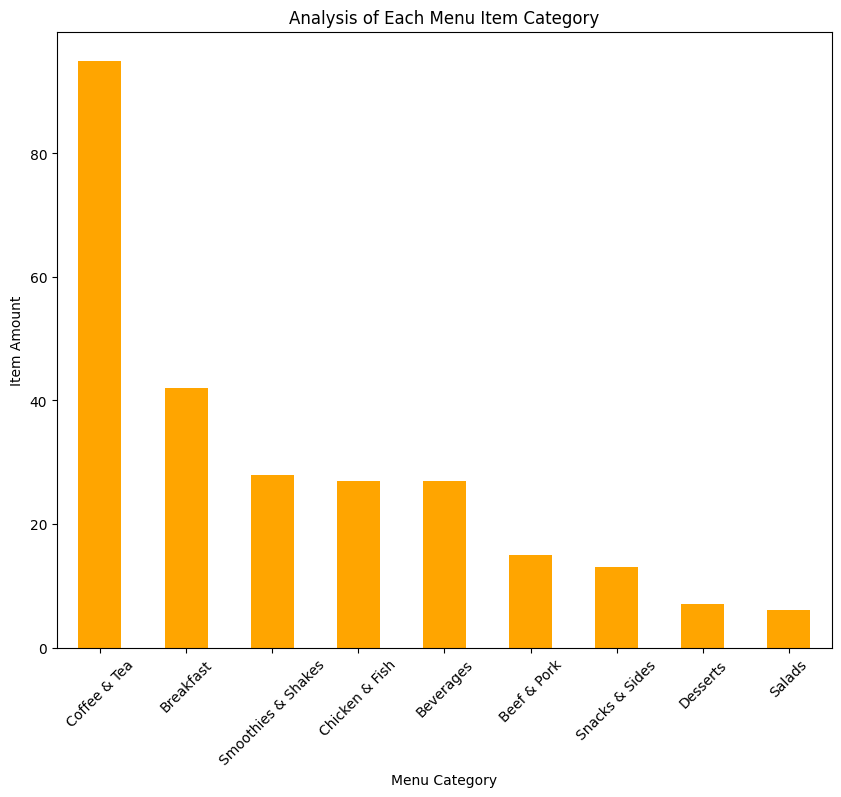

In [42]:
# Displaying the bar plot graph which shows the analysis of each menu item
plt.figure(figsize = (10, 8))
menu_category = data_file.Category.value_counts()
menu_category.plot.bar(color = ['orange'])
plt.title("Analysis of Each Menu Item Category")
plt.ylabel("Item Amount")
plt.xlabel("Menu Category")
plt.xticks(rotation = 45)
plt.show()


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


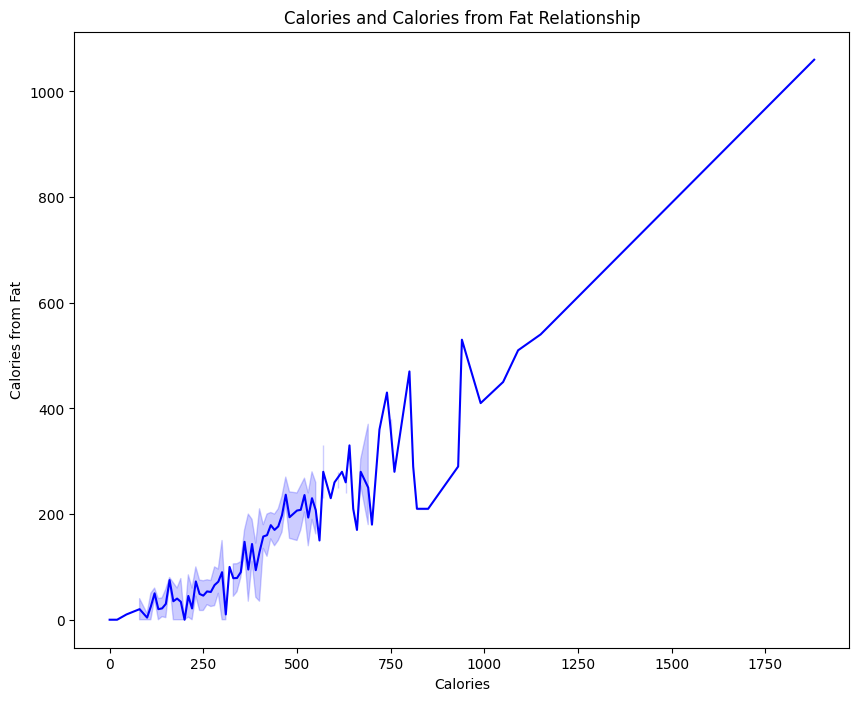

In [43]:
# Displaying the line plot graph which shows the analysis of each menu item
plt.figure(figsize = (10, 8))
sns.lineplot(x ='Calories', y = 'Calories from Fat', data = data_file.sort_values('Calories'), color = 'blue')
plt.title("Calories and Calories from Fat Relationship")
plt.ylabel("Calories from Fat")
plt.xlabel("Calories")
plt.show()

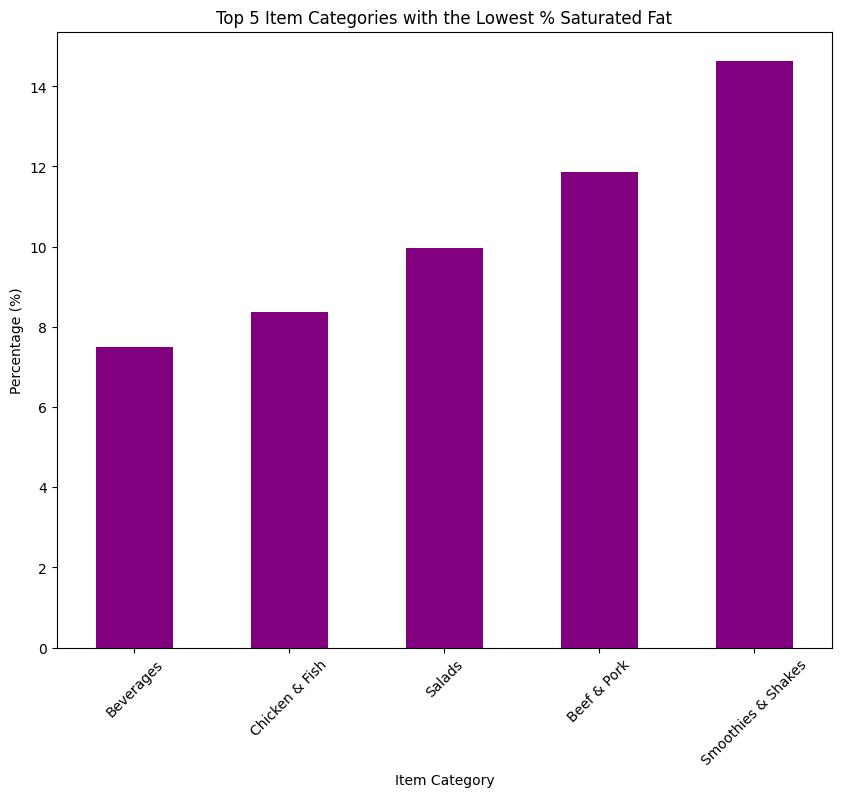

In [44]:
# Displaying the top 5 food categories with lowest saturated fat
top_5_categories = data_file.groupby('Category')['saturated_fat_ratio'].mean().nsmallest(5)
plt.figure(figsize=(10, 8))
top_5_categories. plot.bar (color= ['purple'])
plt.title("Top 5 Item Categories with the Lowest % Saturated Fat")
plt.xlabel("Item Category")
plt.ylabel("Percentage (%)")
plt.xticks(rotation = 45)
plt.show()



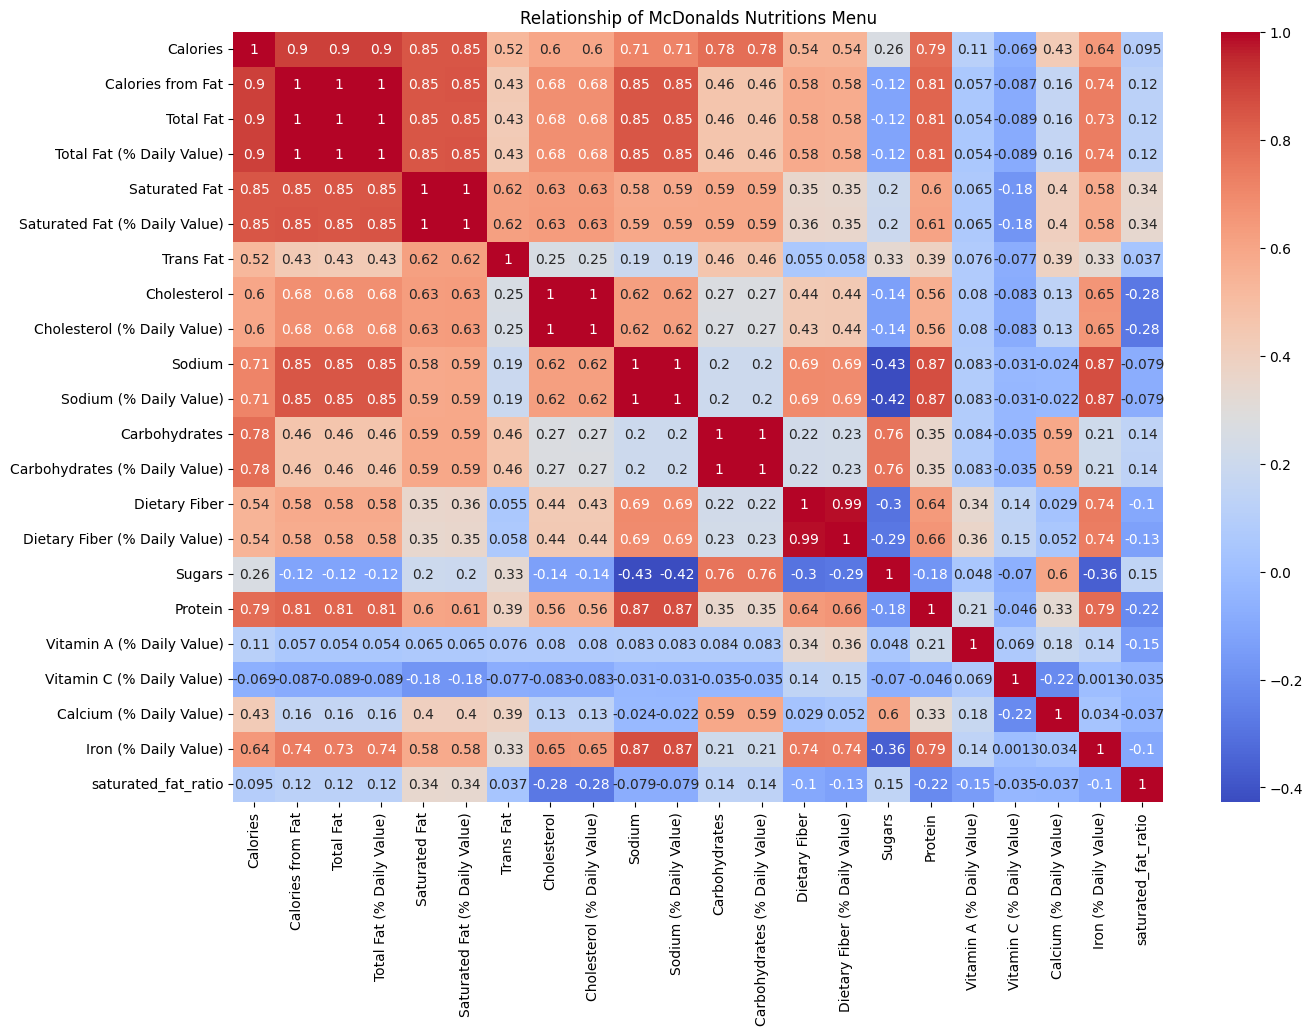

In [45]:
# Displaying the heatmap which shows the relationship of the nutritions menu
numeric_data = data_file.select_dtypes(include=['float64', 'int64'])
plt.figure(figsize=(15, 10))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.title('Relationship of McDonalds Nutritions Menu')
plt.show()



In [46]:
#  Recommendations based on the EDA:

# Divide the menu items into groups, using segmentation analysis. Examine each category's nutritional content in order to spot trends and understand variances.

# Analysis of Optimization which you can look into ways to best choose meals to satisfy particular dietary needs. To establish out how few items from the menu are required to meet 
# daily requirements for nutrition while consuming the fewest calories possible or optimizing nutrient density.

# Recommendations for Menu Items by using the results of your analysis, suggest healthier menu items or changes that patrons can make to enhance the 
# nutritional content of their meals. This can entail recommending lower-calorie substitutes, emphasizing foods with more protein, or pointing out options with less sodium.